In [ ]:
print("hello colab")

hello colab


In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target

In [ ]:
X[0]

array([5.1, 3.5, 1.4, 0.2])

In [ ]:
y[0]

np.int64(0)

In [ ]:
print("ขนาดข้อมูล", X.shape)
print("สิ่งที่วัด", iris.feature_names)
print("สายพันธุ์", iris.target_names)
print("จำนวนต่อสายพันธุ์", np.bincount(y))
print("ค่าต่ำสุดแต่ละคอลัมน์", X.min(axis=0))
print("ค่าสูงสุดแต่ละคอลัมน์", X.max(axis=0))

ขนาดข้อมูล (150, 4)
สิ่งที่วัด ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
สายพันธุ์ ['setosa' 'versicolor' 'virginica']
จำนวนต่อสายพันธุ์ [50 50 50]
ค่าต่ำสุดแต่ละคอลัมน์ [4.3 2.  1.  0.1]
ค่าสูงสุดแต่ละคอลัมน์ [7.9 4.4 6.9 2.5]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print("กองฝึก", len(X_train), "ดอก")
print("กองสอบ", len(X_test), "ดอก")
print("เฉลยในกองฝึก", np.bincount(y_train))
print("เฉลยในกองสอบ", np.bincount(y_test))

กองฝึก 105 ดอก
กองสอบ 45 ดอก
เฉลยในกองฝึก [31 37 37]
เฉลยในกองสอบ [19 13 13]


In [ ]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print("คะแนนต้นไม้", model.score(X_test, y_test))

คะแนนต้นไม้ 1.0


In [ ]:
from sklearn.tree import export_text

print(export_text(model, feature_names=iris.feature_names))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.60
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.60
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |   |--- petal length (cm) <= 5.45
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- petal length (cm) >  5.45
|   |   |   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- sepal width (cm) <= 3.10
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- sepal width (cm) >  3.10
|   |   |   |   |   |--- class: 1
|   |   |   |--- petal 

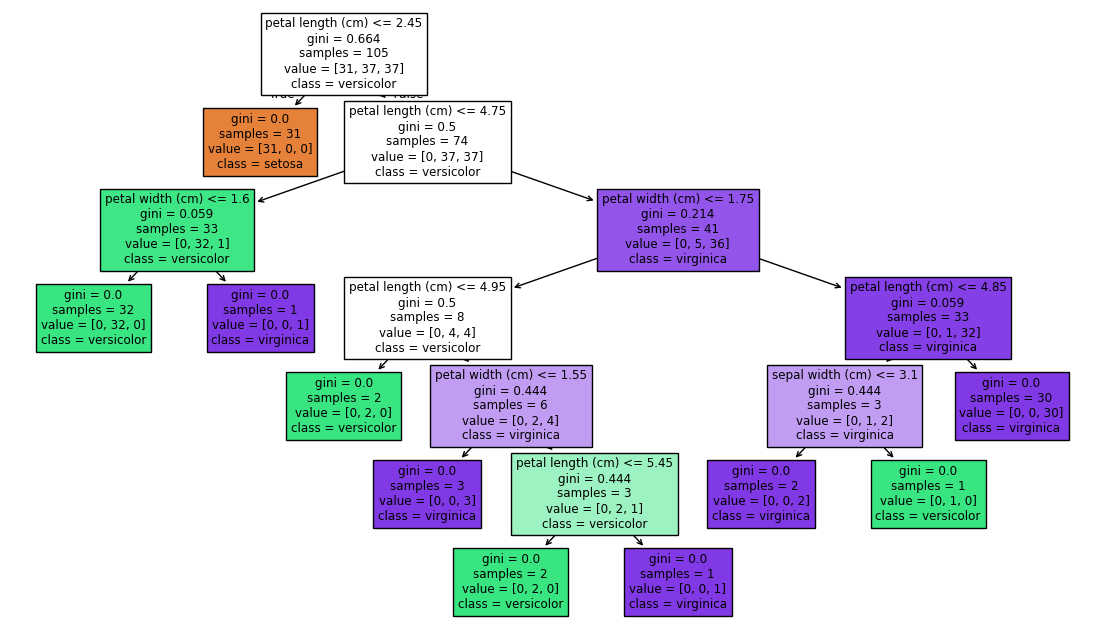

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 8))
plot_tree(model, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True)
plt.show()

In [ ]:
new_flowers = np.array([
    [5.0, 3.4, 1.4, 0.2],
    [6.0, 2.9, 4.5, 1.5],
    [6.5, 3.0, 5.8, 2.2],
])

pred = model.predict(new_flowers)
print("คำตอบ", pred)
print("ชื่อสายพันธุ์", [iris.target_names[p] for p in pred])

คำตอบ [0 1 2]
ชื่อสายพันธุ์ [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [ ]:
print("คะแนนเมื่อสอบด้วยกองฝึก", model.score(X_train, y_train))
print("คะแนนเมื่อสอบด้วยกองสอบ", model.score(X_test, y_test))

คะแนนเมื่อสอบด้วยกองฝึก 1.0
คะแนนเมื่อสอบด้วยกองสอบ 1.0


In [ ]:
from sklearn.datasets import load_wine

wine = load_wine()
Xw, yw = wine.data, wine.target
print("ขนาดข้อมูลไวน์", Xw.shape, "แต่ละตระกูล", np.bincount(yw))

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    Xw, yw, test_size=0.3, random_state=42)

wine_model = DecisionTreeClassifier(random_state=42)
wine_model.fit(Xw_train, yw_train)

print("คะแนนเมื่อสอบด้วยกองฝึก", round(wine_model.score(Xw_train, yw_train), 4))
print("คะแนนเมื่อสอบด้วยกองสอบ", round(wine_model.score(Xw_test, yw_test), 4))

ขนาดข้อมูลไวน์ (178, 13) แต่ละตระกูล [59 71 48]
คะแนนเมื่อสอบด้วยกองฝึก 1.0
คะแนนเมื่อสอบด้วยกองสอบ 0.963


In [ ]:
X_leak = np.vstack([Xw_train, Xw_test])
y_leak = np.concatenate([yw_train, yw_test])

leak_model = DecisionTreeClassifier(random_state=42)
leak_model.fit(X_leak, y_leak)

print("คะแนนของโมเดลที่เห็นข้อสอบล่วงหน้า", round(leak_model.score(Xw_test, yw_test), 4))

คะแนนของโมเดลที่เห็นข้อสอบล่วงหน้า 1.0


In [ ]:
for rs in [0, 1, 7, 42, 100]:
    a, b, c, d = train_test_split(Xw, yw, test_size=0.3, random_state=rs)
    m = DecisionTreeClassifier(random_state=42).fit(a, c)
    print("random_state", rs, "ได้คะแนน", round(m.score(b, d), 4))

random_state 0 ได้คะแนน 0.9259
random_state 1 ได้คะแนน 0.9074
random_state 7 ได้คะแนน 0.9074
random_state 42 ได้คะแนน 0.963
random_state 100 ได้คะแนน 0.8148


## Visualizing the Decision Tree for the Wine Dataset

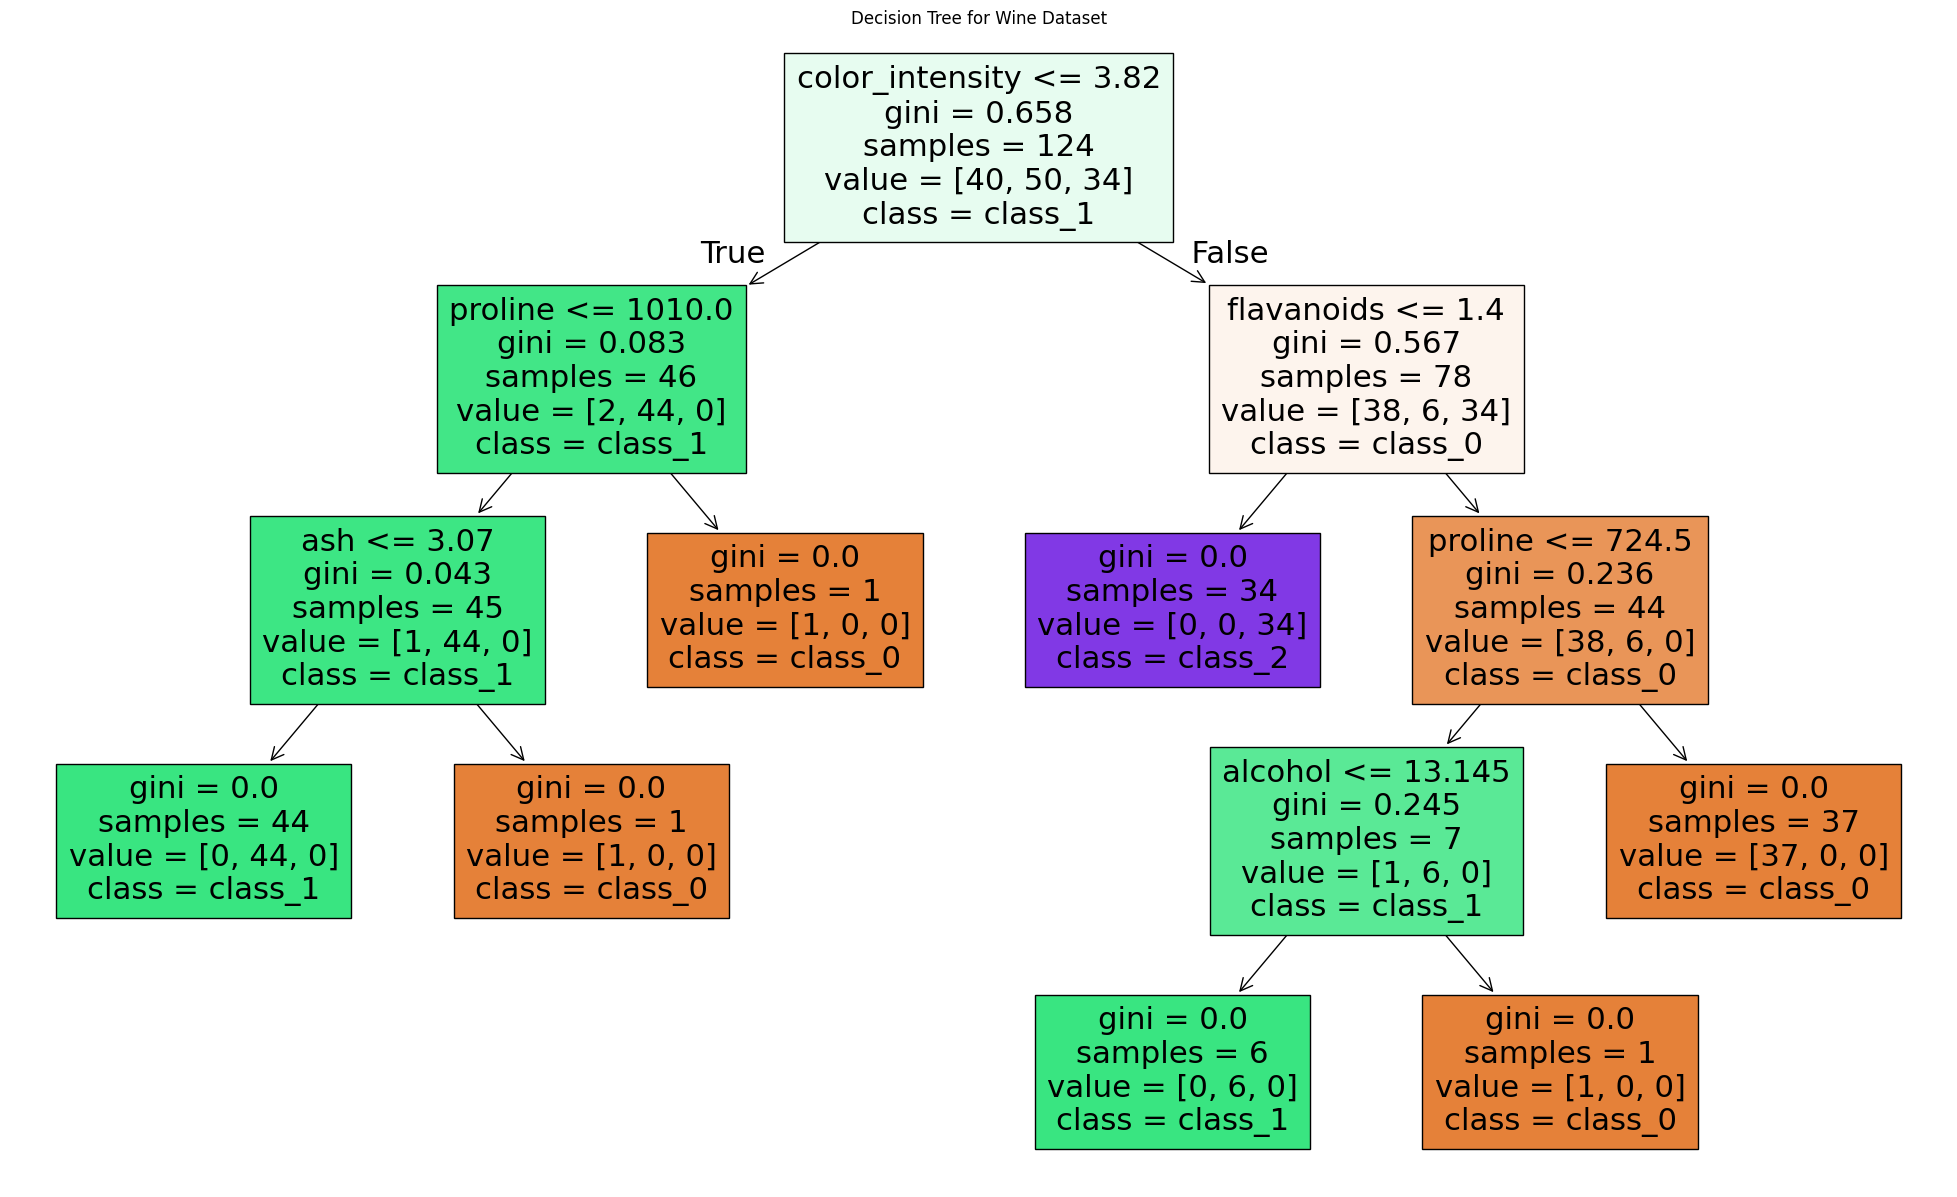

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 15)) # Increased figure size for better spacing
plot_tree(wine_model, feature_names=wine.feature_names,
          class_names=wine.target_names.astype(str), filled=True)
plt.title("Decision Tree for Wine Dataset")
plt.show()

In [ ]:
**เลข 0.2888 ของนักเรียนหลับตาเดา มาจากการหารเลขอะไรด้วยอะไร**
    เลข 0.2888 (หรือ 0.2889 โดยประมาณ) มาจากการหารจำนวนตัวอย่างของคลาสที่มีความถี่สูงสุดในชุดทดสอบ (13 ตัวอย่าง) ด้วยจำนวนตัวอย่างทั้งหมดในชุดทดสอบ (45 ตัวอย่าง) ครับ (13 / 45 ≈ 0.2889)

In [ ]:
**กฎข้อแรกที่ต้นไม้ค้นพบเองคืออะไร และแยกสายพันธุ์ไหนออกได้ทันที**
    กฎข้อแรกที่ต้นไม้ค้นพบคือ `petal length (cm) <= 2.45` ครับ กฎนี้สามารถแยกสายพันธุ์ `class: 0` (setosa) ออกมาได้ทันทีครับ

In [ ]:
**บนชุดข้อมูลไวน์ คะแนนกองฝึกกับกองสอบต่างกันเท่าไหร่ และตัวเลขไหนคือความสามารถจริง**
    บนชุดข้อมูลไวน์ คะแนนกองฝึก (training score) คือ 1.0 และคะแนนกองสอบ (test score) คือ 0.963 ครับ ความแตกต่างคือ 1.0 - 0.963 = 0.037 ตัวเลขที่บ่งบอกถึงความสามารถจริงของโมเดลคือ **0.963** ซึ่งเป็นคะแนนจากชุดทดสอบที่ไม่เคยเห็นมาก่อนครับ

In [ ]:
 **ยกตัวอย่างสถานการณ์จริงมา 1 แบบ ที่ data leakage อาจเกิดโดยไม่ตั้งใจ**
    สถานการณ์หนึ่งที่ Data Leakage อาจเกิดขึ้นโดยไม่ตั้งใจคือ **การคำนวณค่าเฉลี่ยหรือค่าส่วนเบี่ยงเบนมาตรฐานเพื่อการปรับสเกล (scaling) ข้อมูลทั้งชุด** ก่อนที่จะแบ่งข้อมูลออกเป็นชุดฝึก (training set) และชุดทดสอบ (test set) ครับ

    ตัวอย่างเช่น หากคุณต้องการปรับสเกลคอลัมน์ 'ราคา' ของสินค้าโดยใช้ Min-Max Scaling คุณคำนวณ `min(ราคา)` และ `max(ราคา)` จากข้อมูลสินค้าทั้งหมด (รวมทั้งส่วนที่จะเป็นชุดทดสอบ) และนำค่าเหล่านี้ไปใช้ปรับสเกลข้อมูลในชุดฝึกและชุดทดสอบ

    การทำเช่นนี้ทำให้ข้อมูลในชุดฝึก 'รู้' ข้อมูลเกี่ยวกับค่าต่ำสุดและสูงสุดที่มีอยู่ในชุดทดสอบ ซึ่งเป็นข้อมูลที่ควรจะถูกซ่อนไว้เพื่อประเมินประสิทธิภาพของโมเดลอย่างแท้จริงครับ

## Identifying the first splitting feature

In [ ]:
from sklearn.tree import export_text

# Get the textual representation of the tree
tree_rules = export_text(wine_model, feature_names=wine.feature_names)
print(tree_rules)

# Extract the first feature used for splitting
first_split_line = tree_rules.split('\n')[0]
# The first feature will be the one before '<=' or '>' in the first line
import re
match = re.match(r'\|--- (.*?) [<>]', first_split_line)
if match:
    first_feature = match.group(1).strip()
    print(f"\nThe first question (splitting feature) of the wine decision tree is: {first_feature}")
else:
    print("Could not determine the first splitting feature.")

|--- color_intensity <= 3.82
|   |--- proline <= 1010.00
|   |   |--- ash <= 3.07
|   |   |   |--- class: 1
|   |   |--- ash >  3.07
|   |   |   |--- class: 0
|   |--- proline >  1010.00
|   |   |--- class: 0
|--- color_intensity >  3.82
|   |--- flavanoids <= 1.40
|   |   |--- class: 2
|   |--- flavanoids >  1.40
|   |   |--- proline <= 724.50
|   |   |   |--- alcohol <= 13.14
|   |   |   |   |--- class: 1
|   |   |   |--- alcohol >  13.14
|   |   |   |   |--- class: 0
|   |   |--- proline >  724.50
|   |   |   |--- class: 0


The first question (splitting feature) of the wine decision tree is: color_intensity
